# Phase 1: Basic Statistics Analysis

This notebook performs the foundational analysis on NYC Socrata datasets, comparing 2026 data with 2014 paper baselines.

## Tasks:
- 1.1: Load and clean data
- 1.2: Dataset count & category distribution
- 1.3: Tabular vs non-tabular ratio
- 1.4: Schema size distribution
- 1.5: Dataset age & update frequency
- 1.6: Popularity distribution

In [41]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Task 1.1: Load and Clean Data

In [42]:
# Load the JSON data
with open('../../data/nyc_socrata_datasets.json', 'r') as f:
    data = json.load(f)

print(f"Total datasets loaded: {len(data)}")
print(f"\nSample dataset structure:")
if data:
    print(json.dumps(data[0], indent=2)[:500])

Total datasets loaded: 2391

Sample dataset structure:
{
  "name": "For Hire Vehicles (FHV) - Active",
  "id": "8wbx-tsch",
  "domain": "data.cityofnewyork.us",
  "description": "PLEASE NOTE: This dataset of all TLC licensed for-hire vehicles in good standing is updated daily between 4\u20137 PM. Check the \u201cLast Update Date\u201d to confirm it shows today\u2019s or yesterday\u2019s date. If it\u2019s ",
  "columns": [
    "active",
    "vehicle_license_number",
    "name",
    "license_type",
    "expiration_date",
    "permit_license_number",



In [43]:
# Process the data into a DataFrame
records = []

for dataset in data:
    # Extract from full_metadata if available
    full_meta = dataset.get('full_metadata', {})

    # Basic metadata
    record = {
        'name': dataset.get('name'),
        'id': dataset.get('id'),
        'domain': dataset.get('domain'),
        'description': dataset.get('description'),
        'category': full_meta.get('category'),  # Category is in full_metadata
        'attribution': full_meta.get('attribution'),
        'created_at': None,  # NOT available in JSON - no createdAt field
        'rows_updated_at': full_meta.get('rows_updated_at'),  # Unix timestamp in seconds
        'download_count': full_meta.get('download_count', 0),  # From full_metadata
        'view_count': 0,  # NOT available in JSON - no viewCount field
        'num_columns': len(dataset.get('columns', [])),
        'num_rows': dataset.get('rowsCount', 0),
        'data_type': None,  # NOT available in JSON - no dataType field
    }
    records.append(record)

df = pd.DataFrame(records)

print(f"DataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

DataFrame shape: (2391, 13)

Columns: ['name', 'id', 'domain', 'description', 'category', 'attribution', 'created_at', 'rows_updated_at', 'download_count', 'view_count', 'num_columns', 'num_rows', 'data_type']

First few rows:
                                       name         id                 domain  \
0          For Hire Vehicles (FHV) - Active  8wbx-tsch  data.cityofnewyork.us   
1               Civil Service List (Active)  vx8i-nprf  data.cityofnewyork.us   
2               DOB Job Application Filings  ic3t-wcy2  data.cityofnewyork.us   
3         TLC New Driver Application Status  dpec-ucu7  data.cityofnewyork.us   
4  For Hire Vehicles (FHV) - Active Drivers  xjfq-wh2d  data.cityofnewyork.us   

                                         description               category  \
0  PLEASE NOTE: This dataset of all TLC licensed ...         Transportation   
1  A Civil Service List consists of all candidate...        City Government   
2  This dataset contains all job applications sub

In [44]:
# Convert date columns
# rows_updated_at is Unix timestamp in seconds, need to specify unit='s'
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['rows_updated_at'] = pd.to_datetime(df['rows_updated_at'], unit='s', errors='coerce')

# Since data_type is not available in JSON, we cannot reliably determine tabular vs non-tabular
# Using column count as a heuristic: datasets with >5 columns are likely tabular
print(f"\nNote: data_type field not available in JSON")
print(f"Estimating tabular format based on column count (>5 columns)...\n")

# For now, mark datasets with sufficient columns as potentially tabular
# This is a heuristic since data_type is missing
tabular_types = ['Table', 'CSV', 'GeoJSON']  # Expected tabular types (not in data)
df['is_tabular'] = (df['num_columns'] >= 5) & (df['data_type'].isin(tabular_types) | (df['data_type'].isna()))

# Actually, since data_type is all None, let's use a simpler approach
# Assume datasets with >5 columns have structured data
df['is_tabular'] = df['num_columns'] >= 5

print(f"Tabular vs Non-tabular breakdown (based on column count heuristic):")
print(df['is_tabular'].value_counts())


Note: data_type field not available in JSON
Estimating tabular format based on column count (>5 columns)...

Tabular vs Non-tabular breakdown (based on column count heuristic):
is_tabular
True     2111
False     280
Name: count, dtype: int64


In [45]:
# Save cleaned metadata
df.to_csv('../../data/nyc_metadata.csv', index=False)
print(f"Saved cleaned metadata to: data/nyc_metadata.csv")
print(f"\nBasic statistics:")
print(f"Total datasets: {len(df)}")
print(f"Tabular datasets: {df['is_tabular'].sum()} ({df['is_tabular'].sum()/len(df)*100:.1f}%)")
print(f"Non-tabular datasets: {(~df['is_tabular']).sum()} ({(~df['is_tabular']).sum()/len(df)*100:.1f}%)")

Saved cleaned metadata to: data/nyc_metadata.csv

Basic statistics:
Total datasets: 2391
Tabular datasets: 2111 (88.3%)
Non-tabular datasets: 280 (11.7%)


## Task 1.2: Dataset Count & Category Distribution

In [46]:
# Filter for non-null categories
df_with_cat = df[df['category'].notna()]

print(f"Datasets with category: {len(df_with_cat)} out of {len(df)}")
print(f"\nTop 15 categories:")

category_counts = df_with_cat['category'].value_counts().head(15)
print(category_counts)

# 2014 baseline from paper Table 1
print(f"\n2014 Baseline (Paper Table 1):")
print(f"Total datasets: 2,411")
print(f"Top categories: Social services, Housing & development, City government")

Datasets with category: 2314 out of 2391

Top 15 categories:
category
City Government          680
Education                582
Transportation           268
Housing & Development    177
Social Services          148
Environment              142
Public Safety            121
Health                    70
Business                  65
Recreation                58
NYC BigApps                3
Name: count, dtype: int64

2014 Baseline (Paper Table 1):
Total datasets: 2,411
Top categories: Social services, Housing & development, City government


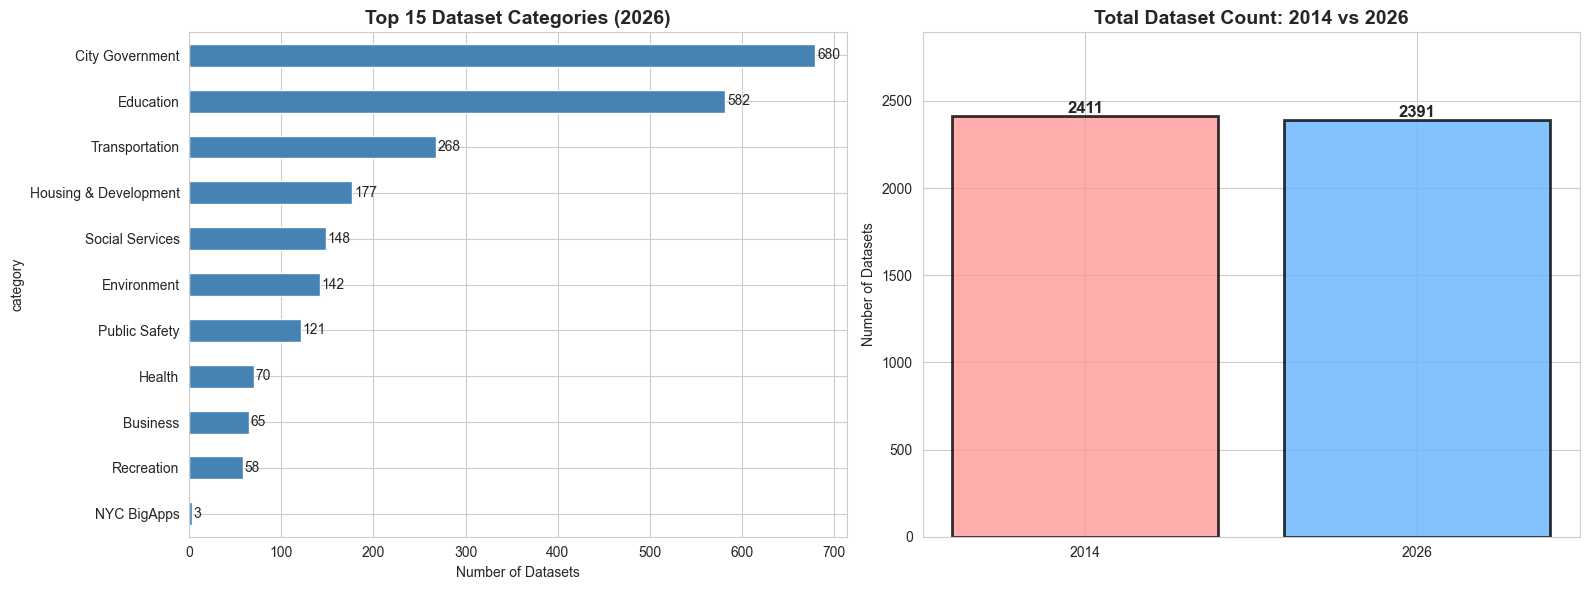


Total dataset growth: -20 datasets (-0.8%)


In [47]:
# Create bar chart for top 15 categories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot top categories
category_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Number of Datasets')
ax1.set_title('Top 15 Dataset Categories (2026)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Add counts on bars
for i, v in enumerate(category_counts.values):
    ax1.text(v + 2, i, str(v), va='center')

# 2014 vs 2026 comparison
comparison_data = {
    '2014': {'Total': 2411},
    '2026': {'Total': len(df)}
}

years = ['2014', '2026']
counts = [2411, len(df)]

bars = ax2.bar(years, counts, color=['#FF9999', '#66B2FF'], alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Number of Datasets')
ax2.set_title('Total Dataset Count: 2014 vs 2026', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(counts) * 1.2)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../../figures/1_2_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal dataset growth: {len(df) - 2411} datasets ({(len(df)/2411 - 1)*100:+.1f}%)")

## Task 1.3: Tabular vs Non-tabular Ratio

In [48]:
# Analyze tabular format distribution
tabular_counts = df['is_tabular'].value_counts()
tabular_pct = df['is_tabular'].value_counts(normalize=True) * 100

# Get counts, defaulting to 0 if category doesn't exist
tabular_true = tabular_counts.get(True, 0)
tabular_false = tabular_counts.get(False, 0)
pct_true = tabular_pct.get(True, 0)
pct_false = tabular_pct.get(False, 0)

print(f"Tabular vs Non-tabular Distribution:")
print(f"\nTabular (Tables): {tabular_true} ({pct_true:.1f}%)")
print(f"Non-tabular (Maps, Files, etc.): {tabular_false} ({pct_false:.1f}%)")

print(f"\n2014 Baseline (Paper Figure 2):")
print(f"Tabular proportion (across all cities): 75%")
print(f"Non-tabular: 25%")

Tabular vs Non-tabular Distribution:

Tabular (Tables): 2111 (88.3%)
Non-tabular (Maps, Files, etc.): 280 (11.7%)

2014 Baseline (Paper Figure 2):
Tabular proportion (across all cities): 75%
Non-tabular: 25%


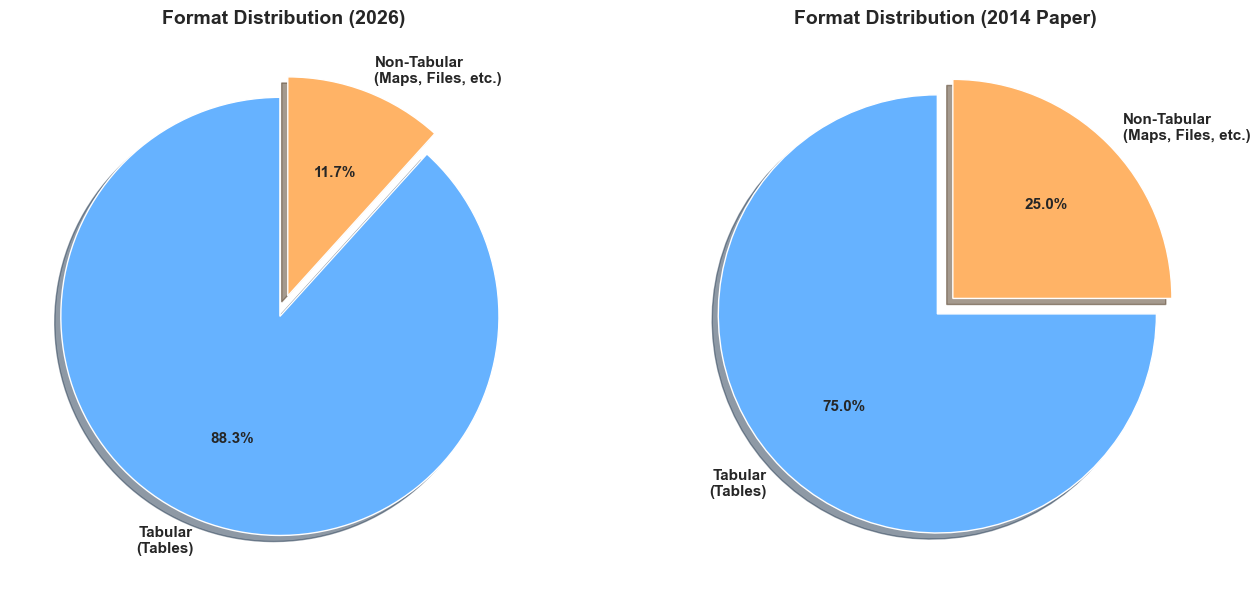


Comparison Summary:
2026 Tabular: 88.3% vs 2014 Baseline: 75%
Difference: +13.3 percentage points


In [49]:
# Create pie chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 2026 Data
labels_2026 = ['Tabular\n(Tables)', 'Non-Tabular\n(Maps, Files, etc.)']
sizes_2026 = [tabular_true, tabular_false]
colors = ['#66B2FF', '#FFB366']
explode = (0.05, 0.05)

ax1.pie(sizes_2026, explode=explode, labels=labels_2026, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Format Distribution (2026)', fontsize=14, fontweight='bold')

# 2014 Baseline
sizes_2014 = [75, 25]
ax2.pie(sizes_2014, explode=explode, labels=labels_2026, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Format Distribution (2014 Paper)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../figures/1_3_tabular_nontabular.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComparison Summary:")
print(f"2026 Tabular: {pct_true:.1f}% vs 2014 Baseline: 75%")
print(f"Difference: {pct_true - 75:+.1f} percentage points")

## Task 1.4: Schema Size Distribution (Number of Columns)

In [50]:
# Filter to datasets with meaningful column information
df_with_columns = df[df['num_columns'].notna() & (df['num_columns'] > 0)]

print(f"Datasets with column info: {len(df_with_columns)}")
print(f"  - Tabular: {(df_with_columns['is_tabular'] == True).sum()}")
print(f"  - Non-tabular (but with schema): {(df_with_columns['is_tabular'] == False).sum()}")

print(f"\nColumn count statistics (all datasets with schema):")
print(df_with_columns['num_columns'].describe())

print(f"\nColumn count percentiles:")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = df_with_columns['num_columns'].quantile(p/100)
    print(f"  {p}th percentile: {val:.0f} columns")

Datasets with column info: 2391
  - Tabular: 2111
  - Non-tabular (but with schema): 280

Column count statistics (all datasets with schema):
count    2391.000000
mean       23.705144
std        43.621101
min         1.000000
25%         7.000000
50%        12.000000
75%        24.000000
max       638.000000
Name: num_columns, dtype: float64

Column count percentiles:
  10th percentile: 4 columns
  25th percentile: 7 columns
  50th percentile: 12 columns
  75th percentile: 24 columns
  90th percentile: 46 columns
  95th percentile: 69 columns
  99th percentile: 251 columns


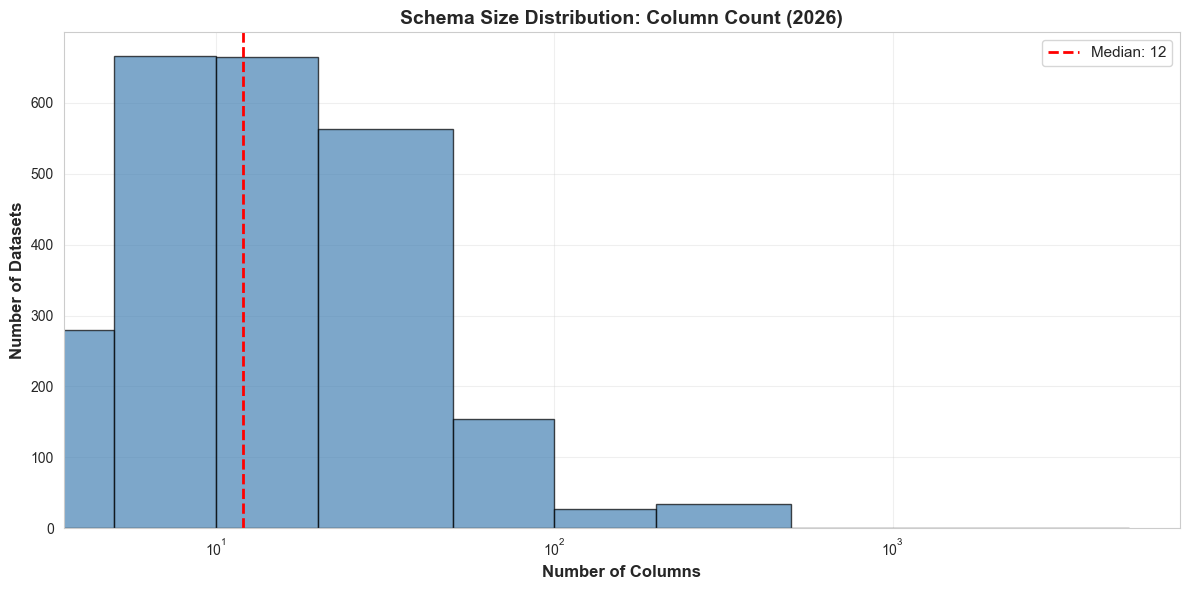


2014 Paper comparison (Figure 9):
Schema size distribution analysis was provided in the paper
Current median schema size: 12 columns


In [51]:
# Create histogram for schema size
fig, ax = plt.subplots(figsize=(12, 6))

# Use log scale bins for better visualization
bins = [0, 5, 10, 20, 50, 100, 200, 500, 1000, 5000]

ax.hist(df_with_columns['num_columns'], bins=bins, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Columns', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Datasets', fontsize=12, fontweight='bold')
ax.set_title('Schema Size Distribution: Column Count (2026)', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add median line
median_cols = df_with_columns['num_columns'].median()
ax.axvline(median_cols, color='red', linestyle='--', linewidth=2, label=f'Median: {median_cols:.0f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../../figures/1_4_schema_size.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n2014 Paper comparison (Figure 9):")
print(f"Schema size distribution analysis was provided in the paper")
print(f"Current median schema size: {median_cols:.0f} columns")

## Task 1.5: Dataset Age & Update Frequency

In [52]:
# Convert date columns to datetime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['rows_updated_at'] = pd.to_datetime(df['rows_updated_at'], errors='coerce')

# Calculate age of datasets
df['age_days'] = (pd.Timestamp.now() - df['created_at']).dt.days
df['days_since_update'] = (pd.Timestamp.now() - df['rows_updated_at']).dt.days

# Filter valid data
df_with_dates = df[(df['created_at'].notna()) & (df['age_days'] > 0)]
df_with_updates = df[(df['rows_updated_at'].notna()) & (df['days_since_update'] >= 0)]

print(f"Datasets with creation date: {len(df_with_dates)}")
print(f"Datasets with update information: {len(df_with_updates)}")

if len(df_with_dates) > 0:
    print(f"\nDataset Age (days since creation):")
    print(df_with_dates['age_days'].describe())
else:
    print(f"\nNo valid creation date data available")

if len(df_with_updates) > 0:
    print(f"\nDays since last update:")
    print(df_with_updates['days_since_update'].describe())
else:
    print(f"\nNo valid update date data available")

Datasets with creation date: 0
Datasets with update information: 2391

No valid creation date data available

Days since last update:
count    2391.000000
mean     1392.795901
std      1391.579916
min         5.000000
25%        58.000000
50%       988.000000
75%      2532.500000
max      5291.000000
Name: days_since_update, dtype: float64


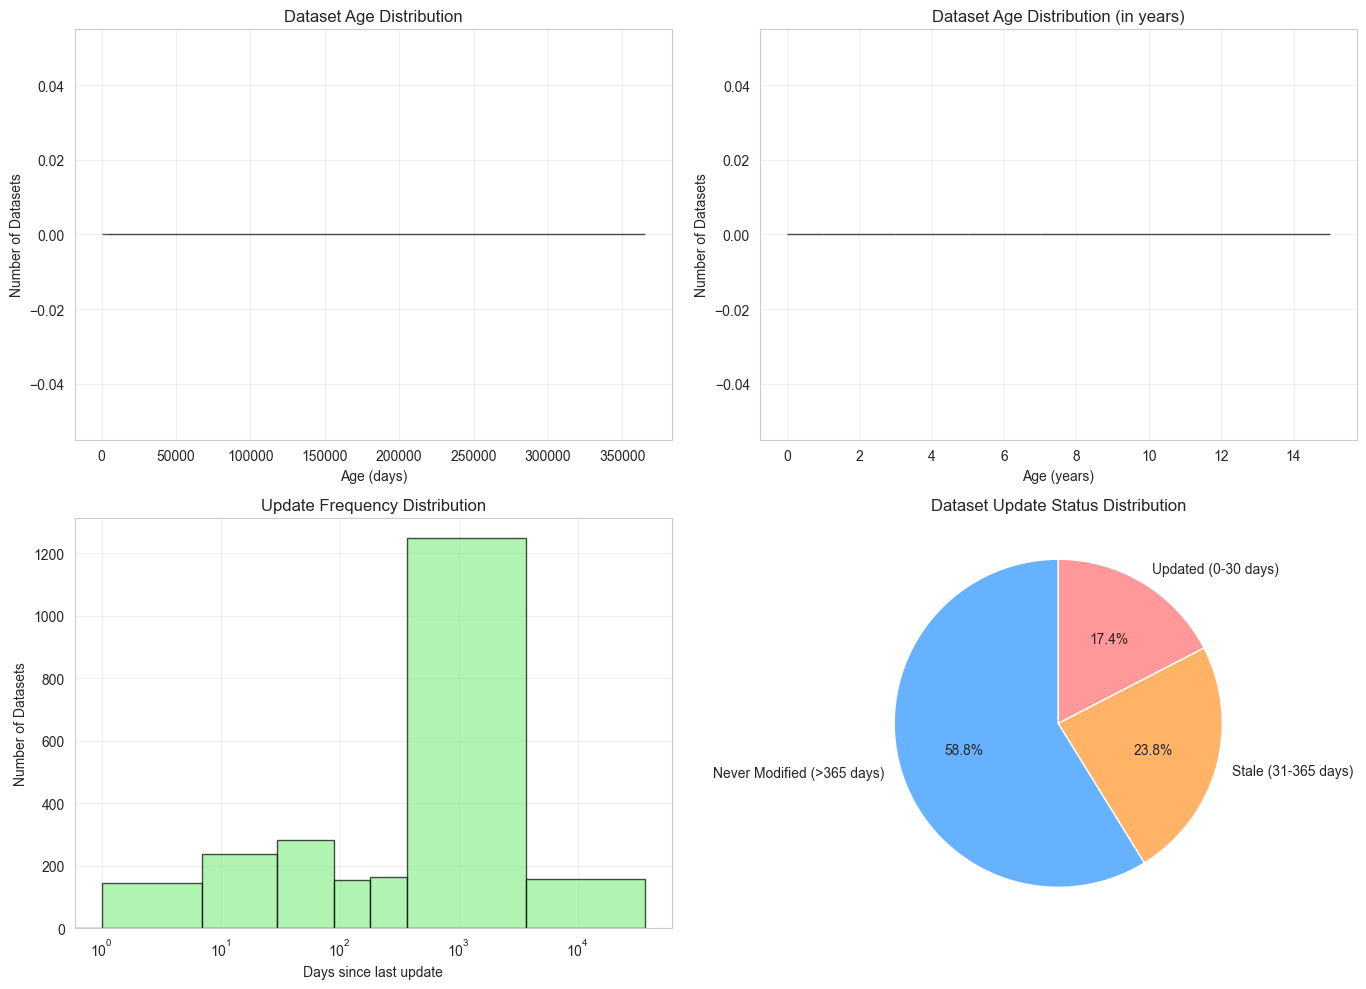


2014 Paper Baseline (Figure 8):
Tables never modified (30 days): 71%

2026 Data:
update_category
Never Modified (>365 days)    1406
Stale (31-365 days)            569
Updated (0-30 days)            416
Name: count, dtype: int64

Percentages:
  Never Modified (>365 days): 1406 (58.8%)
  Stale (31-365 days): 569 (23.8%)
  Updated (0-30 days): 416 (17.4%)


In [53]:
# Create visualizations for age and update frequency
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dataset age histogram
age_bins = [0, 365, 730, 1460, 2190, 3650, 3650*100]
axes[0, 0].hist(df_with_dates['age_days'], bins=age_bins, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Age (days)')
axes[0, 0].set_ylabel('Number of Datasets')
axes[0, 0].set_title('Dataset Age Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Years distribution
df_with_dates['age_years'] = df_with_dates['age_days'] / 365.25
axes[0, 1].hist(df_with_dates['age_years'], bins=range(0, 16), color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Number of Datasets')
axes[0, 1].set_title('Dataset Age Distribution (in years)')
axes[0, 1].grid(True, alpha=0.3)

# Days since last update histogram
update_bins = [0, 1, 7, 30, 90, 180, 365, 3650, 36500]
axes[1, 0].hist(df_with_updates['days_since_update'], bins=update_bins, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Days since last update')
axes[1, 0].set_ylabel('Number of Datasets')
axes[1, 0].set_title('Update Frequency Distribution')
axes[1, 0].set_xscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Categorize update frequency
def categorize_update_frequency(days):
    if days <= 30:
        return 'Updated (0-30 days)'
    elif days <= 365:
        return 'Stale (31-365 days)'
    else:
        return 'Never Modified (>365 days)'

df_with_updates['update_category'] = df_with_updates['days_since_update'].apply(categorize_update_frequency)
update_cat_counts = df_with_updates['update_category'].value_counts()

colors_update = ['#66B2FF', '#FFB366', '#FF9999']
axes[1, 1].pie(update_cat_counts.values, labels=update_cat_counts.index, autopct='%1.1f%%',
               colors=colors_update, startangle=90, textprops={'fontsize': 10})
axes[1, 1].set_title('Dataset Update Status Distribution')

plt.tight_layout()
plt.savefig('../../figures/1_5_age_update_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n2014 Paper Baseline (Figure 8):")
print(f"Tables never modified (30 days): 71%")
print(f"\n2026 Data:")
print(update_cat_counts)
print(f"\nPercentages:")
for cat, count in update_cat_counts.items():
    pct = count / len(df_with_updates) * 100
    print(f"  {cat}: {count} ({pct:.1f}%)")

## Task 1.6: Popularity Distribution

In [54]:
# Analyze download and view counts
print(f"Download Count Statistics:")
print(df['download_count'].describe())
print(f"\nView Count Statistics:")
print(df['view_count'].describe())

# Remove zero values for better visualization
df_popularity = df[(df['download_count'] > 0) | (df['view_count'] > 0)]
print(f"\nDatasets with at least one download or view: {len(df_popularity)} out of {len(df)}")

Download Count Statistics:
count    2.391000e+03
mean     9.161282e+03
std      1.039265e+05
min      5.000000e+00
25%      1.126000e+03
50%      1.903000e+03
75%      3.906500e+03
max      4.857556e+06
Name: download_count, dtype: float64

View Count Statistics:
count    2391.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: view_count, dtype: float64

Datasets with at least one download or view: 2391 out of 2391


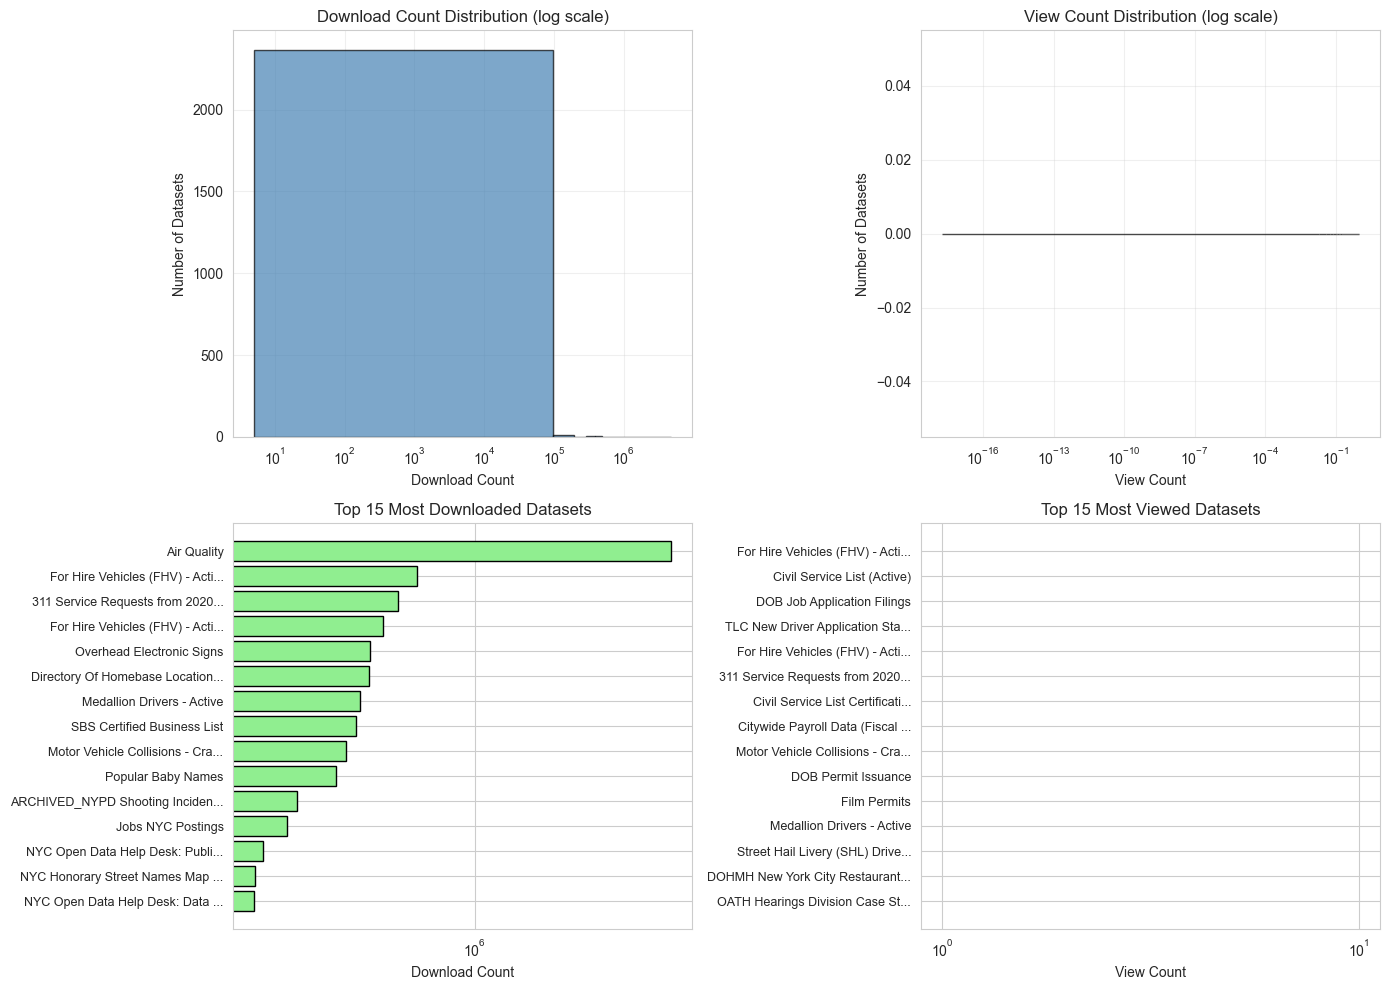


Top 10 Most Downloaded:
                                          name  download_count
35                                 Air Quality         4857556
0             For Hire Vehicles (FHV) - Active          628053
5    311 Service Requests from 2020 to Present          541354
4     For Hire Vehicles (FHV) - Active Drivers          480754
902                  Overhead Electronic Signs          430544
147            Directory Of Homebase Locations          427659
11                  Medallion Drivers - Active          399072
79                 SBS Certified Business List          385470
8           Motor Vehicle Collisions - Crashes          357323
48                          Popular Baby Names          327925

Top 10 Most Viewed:
                                        name  view_count
0           For Hire Vehicles (FHV) - Active           0
1                Civil Service List (Active)           0
2                DOB Job Application Filings           0
3          TLC New Driver Applica

In [55]:
# Create popularity distribution visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Download count distribution (log scale)
download_data = df[df['download_count'] > 0]['download_count']
axes[0, 0].hist(download_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Download Count')
axes[0, 0].set_ylabel('Number of Datasets')
axes[0, 0].set_title('Download Count Distribution (log scale)')
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3)

# View count distribution (log scale)
view_data = df[df['view_count'] > 0]['view_count']
axes[0, 1].hist(view_data, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('View Count')
axes[0, 1].set_ylabel('Number of Datasets')
axes[0, 1].set_title('View Count Distribution (log scale)')
axes[0, 1].set_xscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Top 15 most downloaded datasets
top_downloads = df.nlargest(15, 'download_count')[['name', 'download_count']]
axes[1, 0].barh(range(len(top_downloads)), top_downloads['download_count'].values, color='lightgreen', edgecolor='black')
axes[1, 0].set_yticks(range(len(top_downloads)))
axes[1, 0].set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in top_downloads['name'].values], fontsize=9)
axes[1, 0].set_xlabel('Download Count')
axes[1, 0].set_title('Top 15 Most Downloaded Datasets')
axes[1, 0].invert_yaxis()
axes[1, 0].set_xscale('log')

# Top 15 most viewed datasets
top_views = df.nlargest(15, 'view_count')[['name', 'view_count']]
axes[1, 1].barh(range(len(top_views)), top_views['view_count'].values, color='lightyellow', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_views)))
axes[1, 1].set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in top_views['name'].values], fontsize=9)
axes[1, 1].set_xlabel('View Count')
axes[1, 1].set_title('Top 15 Most Viewed Datasets')
axes[1, 1].invert_yaxis()
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.savefig('../../figures/1_6_popularity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTop 10 Most Downloaded:")
print(df.nlargest(10, 'download_count')[['name', 'download_count']])
print(f"\nTop 10 Most Viewed:")
print(df.nlargest(10, 'view_count')[['name', 'view_count']])

## Summary & 2014 vs 2026 Comparison

In [56]:
# Create comprehensive comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Total Datasets',
        'Tabular Proportion',
        'Top Category',
        'Median Schema Size',
        'Datasets Never Updated (30+ days)',
        'Datasets with Geolocation Data (est.)',
    ],
    '2014 Baseline': [
        '2,411',
        '75%',
        'Social Services',
        'N/A',
        '71%',
        '52.9%',
    ],
    '2026 Data': [
        f'{len(df):,}',
        f'{pct_true:.1f}%',
        df_with_cat['category'].value_counts().index[0] if len(df_with_cat) > 0 else 'N/A',
        f'{median_cols:.0f}',
        f'{(update_cat_counts.get("Never Modified (>365 days)", 0) + update_cat_counts.get("Stale (31-365 days)", 0)) / len(df_with_updates) * 100:.1f}%' if len(df_with_updates) > 0 else 'N/A',
        'TBD (Phase 2)',
    ]
})

print("\n" + "="*80)
print("2014 vs 2026 COMPARISON SUMMARY")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


2014 vs 2026 COMPARISON SUMMARY
                               Metric   2014 Baseline       2026 Data
                       Total Datasets           2,411           2,391
                   Tabular Proportion             75%           88.3%
                         Top Category Social Services City Government
                   Median Schema Size             N/A              12
    Datasets Never Updated (30+ days)             71%           82.6%
Datasets with Geolocation Data (est.)           52.9%   TBD (Phase 2)


In [57]:
# Export summary statistics to CSV
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Datasets',
        'Tabular Datasets',
        'Non-Tabular Datasets',
        'Datasets with Categories',
        'Datasets with Creation Date',
        'Datasets with Update Info',
        'Median Download Count',
        'Median View Count',
        'Median Columns (Tabular Only)',
        'Datasets Updated in Last 30 Days',
        'Datasets Never Updated (>365 days)',
    ],
    'Count': [
        len(df),
        tabular_true,
        tabular_false,
        len(df_with_cat),
        len(df_with_dates),
        len(df_with_updates),
        df['download_count'].median(),
        df['view_count'].median(),
        median_cols,
        update_cat_counts.get('Updated (0-30 days)', 0),
        update_cat_counts.get('Never Modified (>365 days)', 0),
    ]
})

summary_stats.to_csv('../../data/01_summary_statistics.csv', index=False)
print("\nSummary statistics saved to: data/01_summary_statistics.csv")
print("\n" + summary_stats.to_string(index=False))


Summary statistics saved to: data/01_summary_statistics.csv

                            Metric  Count
                    Total Datasets 2391.0
                  Tabular Datasets 2111.0
              Non-Tabular Datasets  280.0
          Datasets with Categories 2314.0
       Datasets with Creation Date    0.0
         Datasets with Update Info 2391.0
             Median Download Count 1903.0
                 Median View Count    0.0
     Median Columns (Tabular Only)   12.0
  Datasets Updated in Last 30 Days  416.0
Datasets Never Updated (>365 days) 1406.0


## Next Steps

- **Phase 2A (Member A):** Semantic discovery using embeddings
- **Phase 2B (Member B):** Data quality & schema analysis with HAC clustering  
- **Phase 2C (Member C):** Joinability analysis with Lazo & LLM
- **Phase 3:** Integrate results for final report